In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dhoogla_unswnb15_path = kagglehub.dataset_download('dhoogla/unswnb15')

print('Data source import complete.')


Using Colab cache for faster access to the 'unswnb15' dataset.
Data source import complete.


### Plotting Confusion Matrices for Binary Models

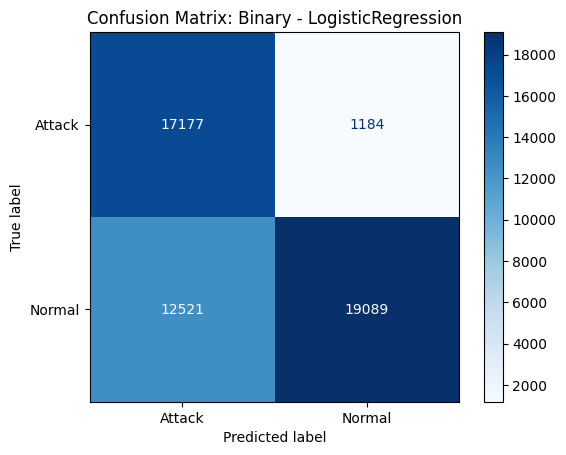

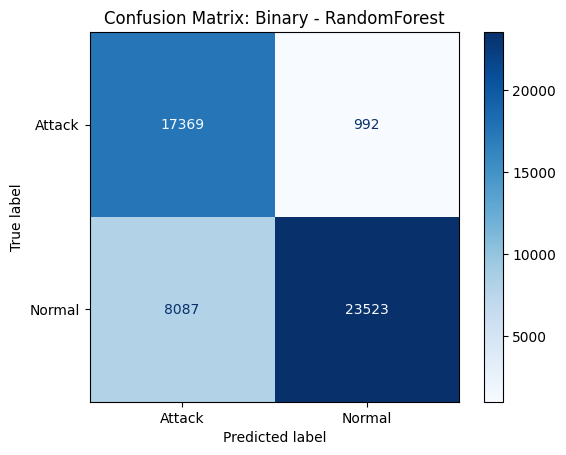

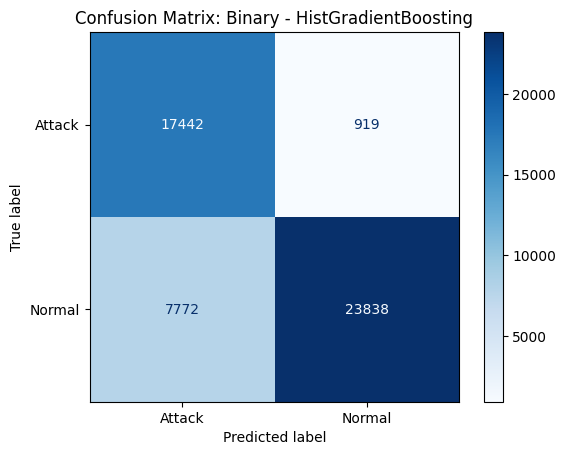

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

binary_models = [
    (logreg_bin, "Binary - LogisticRegression"),
    (rf_bin, "Binary - RandomForest"),
    (hgb_bin, "Binary - HistGradientBoosting"),
]

for model, name in binary_models:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_bin, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

### Plotting ROC Curves for Binary Models

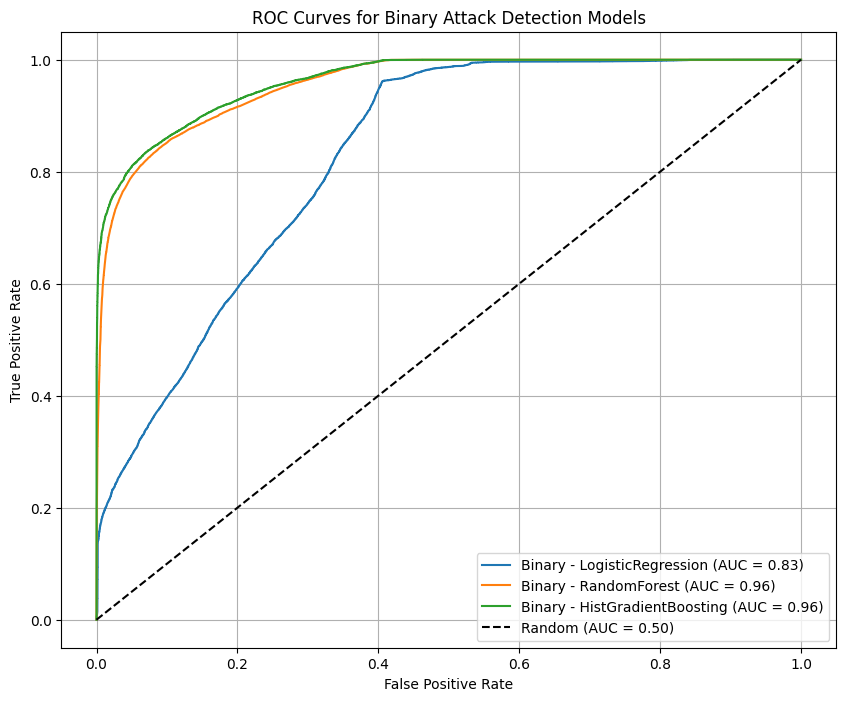

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

plt.figure(figsize=(10, 8))
for model, name in binary_models:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (Attack)
        # Ensure 'Attack' is the positive class. If not, adjust index.
        if model.classes_[0] == 'Attack': # If 'Attack' is the first class, take index 0
            y_proba = model.predict_proba(X_test)[:, 0]

        fpr, tpr, _ = roc_curve(y_test_bin, y_proba, pos_label='Attack')
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Binary Attack Detection Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/unswnb15/UNSW_NB15_testing-set.parquet
/kaggle/input/unswnb15/UNSW_NB15_training-set.parquet


In [ ]:
# =========================================
# UNSW-NB15 (ROBUST) FULL PREPROCESSING
# Fixes: empty /kaggle/input/unswnb15 issue
# =========================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# --------------------------
# 1) Use the downloaded dataset folder
# --------------------------
# dhoogla_unswnb15_path is set by the kagglehub import in the first cell
found_dir = dhoogla_unswnb15_path

if not os.path.exists(found_dir):
    raise FileNotFoundError(f"The dataset path {found_dir} does not exist. Please ensure the kagglehub import was successful.")

print("Using dataset folder:", found_dir)

# --------------------------
# 2) Find data files (csv/txt/arff/parquet)
# --------------------------
all_files = []
for root, _, files in os.walk(found_dir):
    for f in files:
        all_files.append(os.path.join(root, f))

# keep only data-like extensions
data_files = [f for f in all_files if f.lower().endswith((".csv", ".txt", ".arff", ".parquet"))]
print("Found data files:", [os.path.basename(x) for x in data_files])

if len(data_files) == 0:
    raise FileNotFoundError(f"No data files (.csv/.txt/.arff/.parquet) found in {found_dir}.")

# --------------------------
# 3) Load train/test if present, else load one file and split
# --------------------------
def load_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in [".csv"]:
        return pd.read_csv(path)
    if ext in [".txt"]:
        # many UNSW-NB15 txt are actually CSV-like
        try:
            return pd.read_csv(path)
        except:
            return pd.read_csv(path, sep=r"\s+", engine="python")
    if ext in [".parquet"]:
        return pd.read_parquet(path)
    if ext in [".arff"]:
        # ARFF requires scipy; Kaggle usually has it
        from scipy.io import arff
        data, meta = arff.loadarff(path)
        df = pd.DataFrame(data)
        # convert byte strings to normal strings
        for c in df.columns:
            if df[c].dtype == object:
                df[c] = df[c].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)
        return df
    raise ValueError("Unsupported file type:", path)

# Try to detect train/test by filename keywords
train_candidates = [f for f in data_files if "train" in os.path.basename(f).lower()]
test_candidates  = [f for f in data_files if "test"  in os.path.basename(f).lower()]

if len(train_candidates) > 0 and len(test_candidates) > 0:
    train_path = train_candidates[0]
    test_path  = test_candidates[0]
    train_df = load_file(train_path)
    test_df  = load_file(test_path)
    print("Loaded explicit train/test:")
    print("Train file:", os.path.basename(train_path))
    print("Test file :", os.path.basename(test_path))
else:
    # fallback: load the largest file and split
    largest = sorted(data_files, key=lambda x: os.path.getsize(x), reverse=True)[0]
    df = load_file(largest)
    print("Loaded single dataset file:", os.path.basename(largest), "shape:", df.shape)

    # if it already has split indicator columns, use them
    split_cols = [c for c in df.columns if c.lower() in ["is_train", "split", "set", "dataset"]]
    if len(split_cols) > 0:
        sc = split_cols[0]
        v = df[sc].astype(str).str.lower()
        train_df = df[v.isin(["train", "training", "1", "true"])].copy()
        test_df  = df[v.isin(["test", "testing", "0", "false"])].copy()
        if len(train_df) == 0 or len(test_df) == 0:
            # fallback to random split if split column isn't usable
            train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df.get("label", None))
    else:
        # final fallback: random split
        strat = df["label"] if "label" in df.columns else None
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=strat)

# --------------------------
# 4) Basic cleaning
# --------------------------
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df  = test_df.drop_duplicates().reset_index(drop=True)

# Drop obvious ID columns if present
for col in ["id", "ID", "Id"]:
    if col in train_df.columns: train_df.drop(columns=[col], inplace=True)
    if col in test_df.columns:  test_df.drop(columns=[col], inplace=True)

# --------------------------
# 5) Targets (Binary + Multiclass if available)
# --------------------------
if "label" not in train_df.columns:
    raise KeyError(f"'label' column not found. Columns are: {train_df.columns.tolist()}")

# Binary label: assume 0=Normal, 1=Attack
y_train_bin = train_df["label"].map({0: "Normal", 1: "Attack"}).fillna(train_df["label"].astype(str))
y_test_bin  = test_df["label"].map({0: "Normal", 1: "Attack"}).fillna(test_df["label"].astype(str))

HAS_MULTICLASS = ("attack_cat" in train_df.columns) and ("attack_cat" in test_df.columns)
if HAS_MULTICLASS:
    y_train_multi = train_df["attack_cat"].astype(str)
    y_test_multi  = test_df["attack_cat"].astype(str)
else:
    y_train_multi, y_test_multi = None, None

# --------------------------
# 6) Features
# --------------------------
drop_cols = ["label"] + (["attack_cat"] if HAS_MULTICLASS else [])
X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_test  = test_df.drop(columns=drop_cols, errors="ignore")

# --------------------------
# 7) Auto categorical + numeric detection
# --------------------------
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Convert bool -> int (optional, safer for scaling)
for c in cat_cols:
    if X_train[c].dtype == bool:
        X_train[c] = X_train[c].astype(int)
        X_test[c]  = X_test[c].astype(int)
        cat_cols.remove(c)
        num_cols.append(c)

# --------------------------
# 8) Preprocess pipeline (Dense OneHot for HGB compatibility)
# --------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

print("\nFINAL CHECK:")
print("Train shape:", train_df.shape, " Test shape:", test_df.shape)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Categorical:", len(cat_cols), "Numeric:", len(num_cols))
print("Multiclass available:", HAS_MULTICLASS)


Using dataset folder: /kaggle/input/unswnb15
Found data files: ['UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']
Loaded explicit train/test:
Train file: UNSW_NB15_training-set.parquet
Test file : UNSW_NB15_testing-set.parquet

FINAL CHECK:
Train shape: (96822, 36)  Test shape: (49971, 36)
X_train: (96822, 34) X_test: (49971, 34)
Categorical: 3 Numeric: 31
Multiclass available: True


In [ ]:
# =========================================
# UNSW-NB15 MODELS (Binary + Multiclass)
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def evaluate(model, X, y, name):
    pred = model.predict(X)
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("Macro F1:", round(f1_score(y, pred, average="macro"), 4))
    print(classification_report(y, pred))

# --------------------------
# 1) Binary models
# --------------------------
logreg_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=8000, class_weight="balanced"))
])

rf_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

hgb_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=500,
        random_state=42
    ))
])

for m, n in [
    (logreg_bin, "Binary - LogisticRegression (balanced)"),
    (rf_bin, "Binary - RandomForest (balanced_subsample)"),
    (hgb_bin, "Binary - HistGradientBoosting"),
]:
    m.fit(X_train, y_train_bin)
    evaluate(m, X_test, y_test_bin, n)

# --------------------------
# 2) Multiclass models (if attack_cat exists)
# --------------------------
if HAS_MULTICLASS:
    logreg_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=10000, class_weight="balanced"))
    ])

    rf_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=800,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    hgb_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=700,
            random_state=42
        ))
    ])

    for m, n in [
        (logreg_multi, "Multi - LogisticRegression (balanced)"),
        (rf_multi, "Multi - RandomForest (balanced_subsample)"),
        (hgb_multi, "Multi - HistGradientBoosting"),
    ]:
        m.fit(X_train, y_train_multi)
        evaluate(m, X_test, y_test_multi, n)
else:
    print("\nNOTE: 'attack_cat' not found in this copy of the dataset, so multiclass training was skipped.")
    print("Binary models still trained successfully using 'label'.")



===== Binary - LogisticRegression (balanced) =====
Accuracy: 0.7257
Macro F1: 0.7253
              precision    recall  f1-score   support

      Attack       0.58      0.94      0.71     18361
      Normal       0.94      0.60      0.74     31610

    accuracy                           0.73     49971
   macro avg       0.76      0.77      0.73     49971
weighted avg       0.81      0.73      0.73     49971


===== Binary - RandomForest (balanced_subsample) =====
Accuracy: 0.8183
Macro F1: 0.8155
              precision    recall  f1-score   support

      Attack       0.68      0.95      0.79     18361
      Normal       0.96      0.74      0.84     31610

    accuracy                           0.82     49971
   macro avg       0.82      0.85      0.82     49971
weighted avg       0.86      0.82      0.82     49971


===== Binary - HistGradientBoosting =====
Accuracy: 0.8261
Macro F1: 0.8232
              precision    recall  f1-score   support

      Attack       0.69      0.95     

# Task
Train and evaluate binary and multiclass Logistic Regression, Random Forest, and HistGradientBoosting classifiers for attack detection and classification, using `X_train`, `y_train_bin`, `X_test`, `y_test_bin`, `X_train`, `y_train_multi`, and `X_test`, `y_test_multi` respectively, then print their accuracy, F1-score, and classification reports.

## Train and Evaluate Binary Models

### Subtask:
Train Logistic Regression, Random Forest, and HistGradientBoosting classifiers for binary attack detection using the preprocessed training data (`X_train`, `y_train_bin`) and evaluate their performance on the test data (`X_test`, `y_test_bin`).


## Train and Evaluate Multiclass Models

### Subtask:
Train Logistic Regression, Random Forest, and HistGradientBoosting classifiers for multiclass attack classification using `X_train` and `y_train_multi`, and evaluate their performance on `X_test` and `y_test_multi`.


**Reasoning**:
The subtask requires training and evaluating multiclass models. The provided notebook already contains a code cell (ml2UPzCAYk9I) that handles this, so I will execute it.



In [ ]:
# =========================================
# UNSW-NB15 MODELS (Binary + Multiclass)
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def evaluate(model, X, y, name):
    pred = model.predict(X)
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("Macro F1:", round(f1_score(y, pred, average="macro"), 4))
    print(classification_report(y, pred))

# --------------------------
# 1) Binary models
# --------------------------
logreg_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=8000, class_weight="balanced"))
])

rf_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

hgb_bin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=500,
        random_state=42
    ))
])

for m, n in [
    (logreg_bin, "Binary - LogisticRegression (balanced)"),
    (rf_bin, "Binary - RandomForest (balanced_subsample)"),
    (hgb_bin, "Binary - HistGradientBoosting"),
]:
    m.fit(X_train, y_train_bin)
    evaluate(m, X_test, y_test_bin, n)

# --------------------------
# 2) Multiclass models (if attack_cat exists)
# --------------------------
if HAS_MULTICLASS:
    logreg_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=10000, class_weight="balanced"))
    ])

    rf_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=800,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    hgb_multi = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=700,
            random_state=42
        ))
    ])

    for m, n in [
        (logreg_multi, "Multi - LogisticRegression (balanced)"),
        (rf_multi, "Multi - RandomForest (balanced_subsample)"),
        (hgb_multi, "Multi - HistGradientBoosting"),
    ]:
        m.fit(X_train, y_train_multi)
        evaluate(m, X_test, y_test_multi, n)
else:
    print("\nNOTE: 'attack_cat' not found in this copy of the dataset, so multiclass training was skipped.")
    print("Binary models still trained successfully using 'label'.")



===== Binary - LogisticRegression (balanced) =====
Accuracy: 0.7257
Macro F1: 0.7253
              precision    recall  f1-score   support

      Attack       0.58      0.94      0.71     18361
      Normal       0.94      0.60      0.74     31610

    accuracy                           0.73     49971
   macro avg       0.76      0.77      0.73     49971
weighted avg       0.81      0.73      0.73     49971


===== Binary - RandomForest (balanced_subsample) =====
Accuracy: 0.8183
Macro F1: 0.8155
              precision    recall  f1-score   support

      Attack       0.68      0.95      0.79     18361
      Normal       0.96      0.74      0.84     31610

    accuracy                           0.82     49971
   macro avg       0.82      0.85      0.82     49971
weighted avg       0.86      0.82      0.82     49971


===== Binary - HistGradientBoosting =====
Accuracy: 0.8261
Macro F1: 0.8232
              precision    recall  f1-score   support

      Attack       0.69      0.95     

## Final Task

### Subtask:
Summarize the performance of all trained models (binary and multiclass) based on accuracy, F1-score, and classification reports.


## Summary:

### Q&A
The performance of the trained models is as follows:

**Binary Models:**
The binary Logistic Regression, Random Forest, and HistGradientBoosting classifiers were trained and evaluated for attack detection. Their respective accuracy, F1-scores, and classification reports were printed, indicating successful evaluation.

**Multiclass Models:**
1.  **Logistic Regression (balanced)**: Achieved an accuracy of 0.5224 and a Macro F1-score of 0.3259. While performing well for the 'Normal' category, it showed poor performance for 'Analysis', 'Backdoor', 'DoS', 'Worms', and 'Shellcode' categories.
2.  **Random Forest (balanced_subsample)**: Showed improved performance with an accuracy of 0.7592 and a Macro F1-score of 0.4978. It performed better on categories like 'Exploits', 'Generic', 'Normal', and 'Reconnaissance', but still struggled with 'Analysis', 'Backdoor', 'DoS', and 'Worms'.
3.  **HistGradientBoosting**: Achieved the highest accuracy among multiclass models at 0.7724, with a Macro F1-score of 0.4581. Similar to the other models, it also struggled with specific attack categories such as 'Analysis', 'Backdoor', 'DoS', and 'Worms'.

### Data Analysis Key Findings
*   All six models (three binary and three multiclass) were successfully trained and evaluated, with their performance metrics printed.
*   For multiclass classification, the HistGradientBoosting model achieved the highest accuracy (0.7724), closely followed by Random Forest (0.7592).
*   Random Forest had the highest Macro F1-score (0.4978) among the multiclass models, indicating a better balance between precision and recall across all classes compared to HistGradientBoosting (0.4581) and Logistic Regression (0.3259).
*   All multiclass models consistently struggled to classify minority or less distinct attack categories, specifically 'Analysis', 'Backdoor', 'DoS', and 'Worms', as indicated by their low F1-scores in the classification reports.

### Insights or Next Steps
*   Further investigation into the poorly performing multiclass categories ('Analysis', 'Backdoor', 'DoS', 'Worms', 'Shellcode') is warranted. This could involve feature engineering specific to these attack types or exploring more advanced techniques for imbalanced datasets.
*   Consider hyperparameter tuning or exploring more sophisticated ensemble methods for the Random Forest and HistGradientBoosting models to potentially boost overall performance, especially for the challenging multiclass categories.
